# MNIST — From Scratch


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset = pd.read_csv("../data/mnist.csv")

## Visualization


In [3]:
dataset.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
len(dataset)

42000

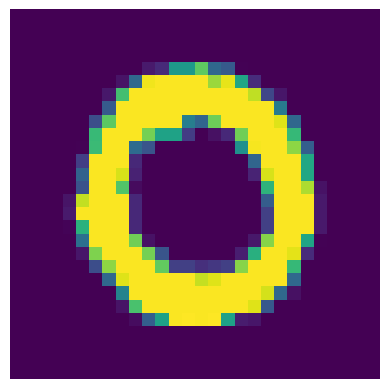

In [5]:
# image 28 x 28 (784 pixels)
example = dataset.iloc[1]
pixels = example.drop("label").values
image = pixels.reshape(28, 28)
plt.imshow(image)
plt.axis('off')
plt.show()

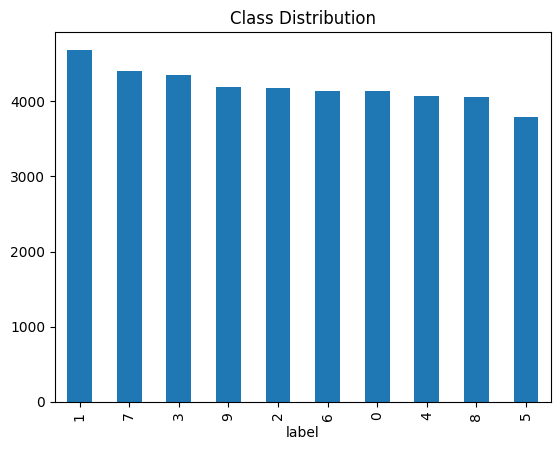

In [6]:
label_counts = dataset["label"].value_counts()
label_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.show()

## Data Preparation


Separation:


In [7]:
# X as the pixel matrix
X = dataset.drop("label", axis=1)
# Y as the label vector (digits)
Y = dataset["label"]

Split 80% / 20%:


In [8]:
index = int(0.8 * 42000)  # 42000 : len(dataset)
X_train = X[:index]
X_test  = X[index:]
Y_train = Y[:index]
Y_test  = Y[index:]

Normalize:


In [9]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

Convert to NumPy:


In [10]:
X_train = X_train.values
X_test  = X_test.values
Y_train = Y_train.values
Y_test  = Y_test.values

## One-Hot Encoding


In [11]:
Y_new = []
for y in Y_train:
    v = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    v[y] = 1
    Y_new.append(v)
Y_train = np.array(Y_new)

## Softmax Function


In [12]:
def softmax(z):
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

## Forward Propagation


In [13]:
def forward(X, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return y_pred

## Loss Function (Cross Entropy)


In [14]:
def loss(y_pred, y_true):
    m = y_true.shape[0]
    log_probs = -np.log(y_pred)
    loss = y_true * log_probs
    return np.sum(loss) / m

## Gradient


In [15]:
def gradient(X, y_pred, y_true):
    m = X.shape[0]
    dz = y_pred - y_true
    dW = np.dot(X.T, dz) / m
    db = np.sum(dz, axis=0, keepdims=True) / m
    return dW, db

## Update


In [16]:
def update(W, b, dW, db, lr):
    W = W - lr * dW
    b = b - lr * db
    return W, b

## Training


In [ ]:
losses = []
pixels = 784
n_classes = 10
W = np.random.randn(pixels, n_classes) * 0.01
b = np.zeros((1, n_classes))
lr = 0.1
epochs = 400

for i in range(epochs):
    y_pred = forward(X_train, W, b)
    l = loss(y_pred, Y_train)
    losses.append(l)
    dW, db = gradient(X_train, y_pred, Y_train)
    W, b = update(W, b, dW, db, lr)
    if i % 100 == 0:
        print(f"epoch {i} :::: loss = {l:.3f}")

plt.plot(losses)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

epoch 0 :::: loss = 2.321


## Prediction


In [22]:
y_pred = forward(X_test, W, b)
predictions = np.argmax(y_pred, axis=1)
accuracy = np.mean(predictions == Y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 89.79%


## Confusion Matrix


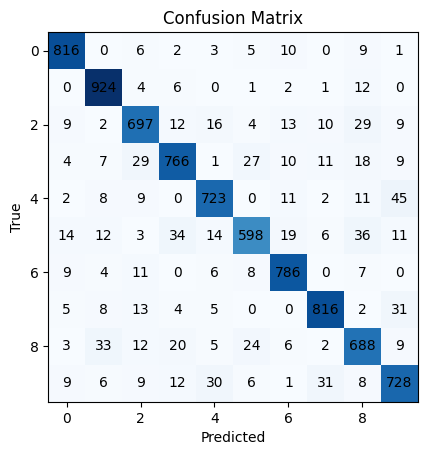

In [23]:
cm = np.zeros((10, 10), dtype=int)
for i in range(len(Y_test)):
    true = Y_test[i]
    p    = predictions[i]
    cm[true][p] += 1

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()

---
## Draw & Predict
Run this cell — a window opens.  
Draw a digit with your mouse, then click **Predict**.


In [26]:
import tkinter as tk
from PIL import Image, ImageDraw

CANVAS_SIZE = 280  # 280px canvas → resized to 28px for the model

class DrawApp:
    def __init__(self, W, b):
        self.W = W
        self.b = b

        self.root = tk.Tk()
        self.root.title("Draw a digit")
        self.root.resizable(False, False)

        # PIL image used to feed the model (black background)
        self.pil_image = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), 0)
        self.draw_tool = ImageDraw.Draw(self.pil_image)

        # Canvas where you draw
        self.canvas = tk.Canvas(
            self.root, width=CANVAS_SIZE, height=CANVAS_SIZE,
            bg="black", cursor="crosshair"
        )
        self.canvas.pack(pady=10, padx=10)

        # Result label
        self.result = tk.Label(
            self.root,
            text="Draw a digit then click Predict",
            font=("Helvetica", 14),
            pady=6
        )
        self.result.pack()

        # Buttons
        frame = tk.Frame(self.root)
        frame.pack(pady=8)

        tk.Button(
            frame, text="Predict",
            font=("Helvetica", 13), bg="#4CAF50", fg="white", padx=14,
            command=self.predict
        ).pack(side="left", padx=8)

        tk.Button(
            frame, text="Clear",
            font=("Helvetica", 13), bg="#f44336", fg="white", padx=14,
            command=self.clear
        ).pack(side="left", padx=8)

        # Mouse drawing events
        self.canvas.bind("<B1-Motion>", self.paint)
        self.canvas.bind("<ButtonRelease-1>", lambda e: None)

        self.root.mainloop()

    def paint(self, event):
        x, y = event.x, event.y
        r = 10  # brush size
        self.canvas.create_oval(x-r, y-r, x+r, y+r, fill="white", outline="white")
        self.draw_tool.ellipse([x-r, y-r, x+r, y+r], fill=255)

    def clear(self):
        self.canvas.delete("all")
        self.pil_image = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), 0)
        self.draw_tool = ImageDraw.Draw(self.pil_image)
        self.result.config(text="Draw a digit then click Predict", fg="black")

    def predict(self):
        # Resize to 28x28, normalize, flatten
        img = self.pil_image.resize((28, 28), Image.LANCZOS)
        img_array = np.array(img) / 255.0
        img_flat  = img_array.reshape(1, 784)

        # Run the model
        probs = forward(img_flat, self.W, self.b)[0]
        pred  = np.argmax(probs)
        conf  = probs[pred] * 100

        self.result.config(
            text=f"Prediction : {pred}     (confidence : {conf:.1f}%)",
            fg="#2196F3",
            font=("Helvetica", 16, "bold")
        )

# Open the window
DrawApp(W, b)